# Tokenizer

## GPT-2

In [1]:
from transformers import GPT2Tokenizer

c:\Users\skd92\.conda\envs\Dragoon\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

In [3]:
print(f"Model Name - {tokenizer.name_or_path}")
print(f"Vocabulary Size - {tokenizer.vocab_size}")
print(f"Model Inputs - {tokenizer.model_input_names}")
print(f"Maximum Context Window - {tokenizer.model_max_length}")

for x, y in tokenizer.special_tokens_map.items():
    print(f"{x} - {y}")

print(f"{tokenizer}")

Model Name - gpt2
Vocabulary Size - 50257
Model Inputs - ['input_ids', 'attention_mask']
Maximum Context Window - 1024
bos_token - <|endoftext|>
eos_token - <|endoftext|>
unk_token - <|endoftext|>
GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})


### Single Text

In [4]:
#Vocab Mapping
vocab_mapping = tokenizer.get_vocab()
print(f"Vocabulary Size = {len(vocab_mapping)}")

print("--------------------------------------------\nText to tokens to token_id\n------------------------------------------")
text = "Amazing"
token = tokenizer.tokenize(text)
token_id = tokenizer.convert_tokens_to_ids(token)

print(f" {text}\n    ⬇     token\n{token}\n    ⬇     token_id\n {token_id} ")

Vocabulary Size = 50257
--------------------------------------------
Text to tokens to token_id
------------------------------------------
 Amazing
    ⬇     token
['Amazing']
    ⬇     token_id
 [42770] 


### Sentence

In [5]:
text = 'I love skating.'
tokens=tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)
decoded_text = tokenizer.decode(token_ids)

print(f"{text}\n{tokens}  <-  {len(tokens)} tokens\n{token_ids}\n{decoded_text}")

I love skating.
['I', 'Ġlove', 'Ġskating', '.']  <-  4 tokens
[40, 1842, 33051, 13]
I love skating.


### Testing Sub-Word Tokenization

In [6]:
from pipeline_helper import get_program_texts

texts = get_program_texts()
for text in texts:
    token = tokenizer.tokenize(text)
    token_id = tokenizer.encode(text)
    print(f"{text} -> {token} -> {token_id}     <- {len(token)} tokens")

program -> ['program'] -> [23065]     <- 1 tokens
programmer -> ['program', 'mer'] -> [23065, 647]     <- 2 tokens
programming -> ['program', 'ming'] -> [23065, 2229]     <- 2 tokens
programmed -> ['program', 'med'] -> [23065, 1150]     <- 2 tokens
programs -> ['program', 's'] -> [23065, 82]     <- 2 tokens


### Rarer Words

In [32]:
rare_texts = ["electroencephalography", "antidisestablishmentarianism", "electromagnetohydrodynamics"]

for text in rare_texts:
    token = tokenizer.tokenize(text)
    token_id = tokenizer.encode(token)

    print(f"{text} -> {token} -> {token_id}     <- {len(token)} tokens")

electroencephalography -> ['elect', 'ro', 'ence', 'phal', 'ography'] -> [[9509], [305], [594], [27451], [4867]]     <- 5 tokens
antidisestablishmentarianism -> ['ant', 'idis', 'establishment', 'arian', 'ism'] -> [[415], [29207], [44390], [3699], [1042]]     <- 5 tokens
electromagnetohydrodynamics -> ['elect', 'rom', 'ag', 'net', 'ohyd', 'rod', 'ynam', 'ics'] -> [[9509], [398], [363], [3262], [15782], [14892], [4989], [873]]     <- 8 tokens


## QWEN-2.5

In [8]:
from transformers import AutoTokenizer
qwen = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

In [9]:
# Qwen Tokenizer Information
print(f"Model Name - {qwen.name_or_path}")
print(f"Vocabulary Size - {qwen.vocab_size}")
print(f"Model Inputs - {qwen.model_input_names}")
print(f"Model Max Context Length - {qwen.model_max_length}")

for x, y in qwen.special_tokens_map.items():
    print(f"{x} - {y}")

Model Name - Qwen/Qwen2.5-0.5B
Vocabulary Size - 151643
Model Inputs - ['input_ids', 'attention_mask']
Model Max Context Length - 131072
eos_token - <|endoftext|>
pad_token - <|endoftext|>


In [10]:
# Testing Qwen Tokenizer
text = "Let's go to the playground."
tokens = qwen.tokenize(text)
token_ids = qwen.encode(tokens)
print(f"text - {text}\ntokens - {tokens} <- {len(tokens)} tokens\ntoken_ids - {token_ids}")

text - Let's go to the playground.
tokens - ['Let', "'s", 'Ġgo', 'Ġto', 'Ġthe', 'Ġplayground', '.'] <- 7 tokens
token_ids - [[10061], [594], [144242, 3346], [144242, 983], [144242, 1782], [144242, 1363, 1951], [13]]


## GPT-2  vs Qwen Tokenizer

In [11]:
texts = "The quick brown fox jumps over the lazy dog."

print("GPT-2")
print("────────────────────────────────────────")
tokens_gpt = tokenizer.tokenize(texts)
token_id_gpt = tokenizer.encode(tokens_gpt)
print(f"text - {texts}\ntokens - {tokens_gpt}\ntoken_ids - {token_id_gpt}")
print(f"Total Tokens - {len(tokens_gpt)}")


print("\nQwen-2.5\n────────────────────────────────────────")
tokens_qwen = qwen.tokenize(texts)
token_id_qwen = qwen.encode(tokens_qwen)
print(f"text - {texts}\ntokens - {tokens_qwen}\ntoken_ids - {token_id_qwen}")
print(f"Total Tokens - {len(tokens_qwen)}")

GPT-2
────────────────────────────────────────
text - The quick brown fox jumps over the lazy dog.
tokens - ['The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']
token_ids - [[464], [128, 254, 24209], [128, 254, 33282], [128, 254, 12792], [128, 254, 73, 8142], [128, 254, 2502], [128, 254, 1169], [128, 254, 75, 12582], [128, 254, 9703], [13]]
Total Tokens - 10

Qwen-2.5
────────────────────────────────────────
text - The quick brown fox jumps over the lazy dog.
tokens - ['The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']
token_ids - [[785], [144242, 27763], [144242, 64461], [144242, 15011], [144242, 73, 11793], [144242, 1975], [144242, 1782], [144242, 49013], [144242, 18457], [13]]
Total Tokens - 10


## BERT

In [12]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [13]:
print(f"Model Name - {bert_tokenizer.name_or_path}")
print(f"Vocabulary Size - {bert_tokenizer.vocab_size}")
print(f"Model Inputs - {bert_tokenizer.model_input_names}")
print(f"Maximum Context Window - {bert_tokenizer.model_max_length}")

Model Name - bert-base-uncased
Vocabulary Size - 30522
Model Inputs - ['input_ids', 'token_type_ids', 'attention_mask']
Maximum Context Window - 512


In [14]:
print("\nBERT-base-uncased\n────────────────────────────────────────────────────────────────")
tokens_bert = bert_tokenizer.tokenize(text)
token_id_bert = bert_tokenizer.convert_tokens_to_ids(tokens_bert)
print(f"text - {text}\ntokens - {tokens_bert}\ntoken_ids - {token_id_bert}")
print(f"Total Tokens - {len(tokens_bert)}")

for x, y in bert_tokenizer.added_tokens_decoder.items():
    print(f"{x} - {y}")


BERT-base-uncased
────────────────────────────────────────────────────────────────
text - Let's go to the playground.
tokens - ['let', "'", 's', 'go', 'to', 'the', 'playground', '.']
token_ids - [2292, 1005, 1055, 2175, 2000, 1996, 14705, 1012]
Total Tokens - 8
0 - [PAD]
100 - [UNK]
101 - [CLS]
102 - [SEP]
103 - [MASK]


## Sub-Word Tokenization -> No. of tokens tests

In [15]:
from pipeline_helper import long_and_rare_sentences, small_sentences

In [16]:
x=0
store_tokens = {}
for sentence in long_and_rare_sentences:
    x+=1

    gpt_tokens = tokenizer.tokenize(sentence)
    qwen_tokens = qwen.tokenize(sentence)
    bert_tokens = bert_tokenizer.tokenize(sentence)

    sent = "s"+str(x)
    store_tokens[sent] = []
    store_tokens[sent].append([len(gpt_tokens), len(qwen_tokens), len(bert_tokens)])


In [17]:
store_tokens

{'s1': [[38, 36, 37]],
 's2': [[40, 39, 40]],
 's3': [[39, 38, 36]],
 's4': [[44, 42, 40]],
 's5': [[38, 41, 41]],
 's6': [[31, 32, 35]],
 's7': [[38, 37, 40]],
 's8': [[35, 34, 33]],
 's9': [[34, 30, 33]],
 's10': [[30, 29, 36]],
 's11': [[40, 40, 46]],
 's12': [[28, 27, 27]],
 's13': [[33, 32, 33]],
 's14': [[27, 27, 26]],
 's15': [[33, 34, 36]],
 's16': [[30, 30, 34]],
 's17': [[30, 28, 27]],
 's18': [[28, 27, 29]],
 's19': [[33, 33, 34]],
 's20': [[25, 25, 27]],
 's21': [[31, 31, 34]],
 's22': [[32, 33, 34]],
 's23': [[30, 28, 30]],
 's24': [[28, 27, 29]],
 's25': [[25, 26, 25]],
 's26': [[30, 31, 30]],
 's27': [[27, 27, 33]],
 's28': [[30, 28, 29]],
 's29': [[25, 26, 26]],
 's30': [[30, 30, 32]],
 's31': [[30, 29, 31]],
 's32': [[23, 22, 21]],
 's33': [[27, 28, 26]],
 's34': [[30, 28, 34]],
 's35': [[23, 25, 25]],
 's36': [[25, 25, 27]],
 's37': [[23, 25, 26]],
 's38': [[30, 28, 28]],
 's39': [[29, 29, 30]],
 's40': [[29, 27, 30]],
 's41': [[24, 23, 25]],
 's42': [[24, 24, 25]],
 

# Tokens **->** Embeddings

In [18]:
import torch, torch.nn.functional as fu

In [19]:
from transformers import AutoModel

gpt_model = AutoModel.from_pretrained("gpt2")
qwen_model = AutoModel.from_pretrained("Qwen/Qwen2.5-0.5B")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1517.75it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### GPT-2 Embedding Matrix

In [20]:
text = "Dr.Stone is an amazing anime series."

#Tokenization
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

#Embedding
input_ids = torch.tensor(token_ids)
embeddings_gpt2 = gpt_model.get_input_embeddings()(input_ids)

print(F"{text}\n{tokens}\n{token_ids}\n\n{input_ids}\n{embeddings_gpt2}")

print(f"\nShape = {embeddings_gpt2.shape}")
print(f"Data Type = {(embeddings_gpt2).dtype}")
print(f"Device = {embeddings_gpt2.device}")

Dr.Stone is an amazing anime series.
['Dr', '.', 'Stone', 'Ġis', 'Ġan', 'Ġamazing', 'Ġanime', 'Ġseries', '.']
[6187, 13, 34346, 318, 281, 4998, 11984, 2168, 13]

tensor([ 6187,    13, 34346,   318,   281,  4998, 11984,  2168,    13])
tensor([[ 0.0686, -0.1818,  0.1270,  ...,  0.2014, -0.0042,  0.0294],
        [ 0.0466, -0.0113,  0.0283,  ..., -0.0735,  0.0496,  0.0963],
        [-0.1411, -0.0625,  0.2916,  ..., -0.0723, -0.1107, -0.0946],
        ...,
        [ 0.0776, -0.0037,  0.0891,  ...,  0.0700,  0.0929,  0.1228],
        [ 0.0088,  0.0290,  0.1192,  ...,  0.0545,  0.1034,  0.0429],
        [ 0.0466, -0.0113,  0.0283,  ..., -0.0735,  0.0496,  0.0963]],
       grad_fn=<EmbeddingBackward0>)

Shape = torch.Size([9, 768])
Data Type = torch.float32
Device = cpu


### Qwen-2.5 Embedding Matrix

In [21]:
text = "Dr.Stone is an amazing anime series."

#Tokenization
tokens = qwen.tokenize(text)
token_ids = qwen.convert_tokens_to_ids(tokens)

#Embedding
input_ids = torch.tensor(token_ids)
embeddings_qwen = qwen_model.get_input_embeddings()(input_ids)

print(f"{text}\n{tokens}\n{token_ids}\n\n{input_ids}\n{embeddings_qwen}")
print(f"\nShape = {embeddings_qwen.shape}")
print(f"Data Type = {(embeddings_qwen).dtype}")
print(f"Device = {embeddings_qwen.device}")

Dr.Stone is an amazing anime series.
['Dr', '.St', 'one', 'Ġis', 'Ġan', 'Ġamazing', 'Ġanime', 'Ġseries', '.']
[8847, 7758, 603, 374, 458, 7897, 22809, 4013, 13]

tensor([ 8847,  7758,   603,   374,   458,  7897, 22809,  4013,    13])
tensor([[-0.0146,  0.0070,  0.0066,  ...,  0.0155, -0.0189, -0.0081],
        [-0.0020, -0.0060,  0.0084,  ...,  0.0020,  0.0070, -0.0118],
        [-0.0024,  0.0356, -0.0060,  ...,  0.0025,  0.0063, -0.0178],
        ...,
        [ 0.0102, -0.0037,  0.0017,  ...,  0.0128,  0.0179,  0.0092],
        [ 0.0171,  0.0077,  0.0031,  ...,  0.0099, -0.0085,  0.0005],
        [-0.0149,  0.0060, -0.0233,  ...,  0.0179,  0.0161, -0.0201]],
       dtype=torch.bfloat16, grad_fn=<EmbeddingBackward0>)

Shape = torch.Size([9, 896])
Data Type = torch.bfloat16
Device = cpu


### BERT Embedding Matrix

In [22]:
text = "Dr.Stone is an amazing anime series."

#Tokenization
tokens = bert_tokenizer.tokenize(text)
token_ids = bert_tokenizer.convert_tokens_to_ids(tokens)

#Embedding
input_ids = torch.tensor(token_ids)
embeddings_bert = bert_model.get_input_embeddings()(input_ids)

print(f"{text}\n{tokens}\n{token_ids}\n\n{input_ids}\n{embeddings_bert}")
print(f"\nShape = {embeddings_bert.shape}")
print(f"Data Type = {(embeddings_bert).dtype}")
print(f"Device = {embeddings_bert.device}")

Dr.Stone is an amazing anime series.
['dr', '.', 'stone', 'is', 'an', 'amazing', 'anime', 'series', '.']
[2852, 1012, 2962, 2003, 2019, 6429, 8750, 2186, 1012]

tensor([2852, 1012, 2962, 2003, 2019, 6429, 8750, 2186, 1012])
tensor([[-0.0309, -0.0400,  0.0307,  ..., -0.0492,  0.0085,  0.0288],
        [-0.0207, -0.0020, -0.0118,  ...,  0.0128,  0.0200,  0.0259],
        [-0.0431, -0.0297, -0.0937,  ..., -0.0373, -0.0459,  0.0042],
        ...,
        [ 0.0055,  0.0254, -0.0192,  ...,  0.0392,  0.0560,  0.0277],
        [ 0.0184, -0.0020, -0.0213,  ..., -0.0060, -0.0369,  0.0220],
        [-0.0207, -0.0020, -0.0118,  ...,  0.0128,  0.0200,  0.0259]],
       grad_fn=<EmbeddingBackward0>)

Shape = torch.Size([9, 768])
Data Type = torch.float32
Device = cpu


### Embedding Matrix

In [23]:
print(qwen_model.get_input_embeddings())
print(qwen_model.dtype)
print(qwen_model.device)

Embedding(151936, 896)
torch.bfloat16
cpu


In [24]:
print(gpt_model.get_input_embeddings())
print(gpt_model.dtype)
print(gpt_model.device)

Embedding(50257, 768)
torch.float32
cpu


In [25]:
#Similarity between gpt sequence and bert sequence matrix
sent1 = embeddings_gpt2.mean(dim=0)
sent2 = embeddings_bert.mean(dim=0)
fu.cosine_similarity(sent1, sent2, dim=0)

tensor(0.0145, grad_fn=<SumBackward1>)

# Finding similarities

## Using GPT-2 - Words Only

In [ ]:
words = ["cat", "dog", "banana", "apple", "rainbow"]

store_embeddings = {}
for word in words:
    text = word
    
    tokens = tokenizer.tokenize(word)
    token_id = tokenizer.convert_tokens_to_ids(tokens)
    input_id_ = torch.tensor(token_id)
    embeddings_gpt2_ = gpt_model.get_input_embeddings()(input_id_)
    store_embeddings[word] = embeddings_gpt2_

In [27]:
s1 = store_embeddings["cat"].squeeze()
s2 = store_embeddings["dog"].squeeze()

print(f"Similarity Score between cat and dog = {round(fu.cosine_similarity(s1, s2, dim=0).item() * 100, 2)}%")

Similarity Score between cat and dog = 38.15%


              cat       dog    banana     apple   rainbow
cat      1.000000  0.381537  0.267502  0.247951  0.276125
dog      0.381537  1.000000  0.237725  0.274597  0.348723
banana   0.267502  0.237725  1.000000  0.286307  0.409835
apple    0.247951  0.274597  0.286307  1.000000  0.326594
rainbow  0.276125  0.348723  0.409835  0.326594  1.000000


<Axes: >

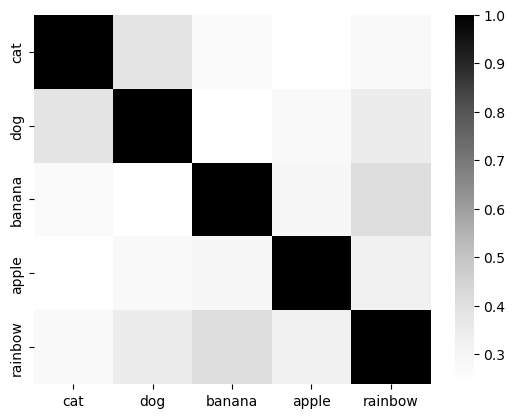

In [28]:
import pandas as pd
import seaborn as sns

sim_scores = {}
for x in words:
    sim_scores[x]=[]
    for y in words:
        s1 = store_embeddings[x].mean(dim=0)
        s2 = store_embeddings[y].mean(dim=0)
        sim_scores[x].append(fu.cosine_similarity(s1, s2, dim=0).item())

print(pd.DataFrame(sim_scores, index=["cat", "dog", "banana", "apple", "rainbow"]))
sns.heatmap(pd.DataFrame(sim_scores, index=["cat", "dog", "banana", "apple", "rainbow"]), cmap='Greys')

## Using GPT-2 Sentences Only

In [41]:
from pipeline_helper import sentence_matrix
sentences = [
    "The cat sat on the mat.",
    "A cat was sitting on the rug.", 
    "She finished her homework quickly.", 
    "She completed her assignment fast.", 
    "The sun is shining brightly."
]

sentence_matrix(sentences, tokenizer=tokenizer)

ImportError: cannot import name 'sentence_matrix' from 'pipeline_helper' (c:\Users\skd92\Main Projects\ai-foundations\ai_foundations_week_1\tokens_1\pipeline_helper.py)